In [1]:
import json
import pandas as pd
from collections import Counter
import shap
import pickle

In [2]:
import os
import sys

project_root = os.path.abspath("..")
sys.path.insert(0, project_root)

In [3]:
from data_gathering.utils.util import clean_text
from classification.utils_finetune import load_dataset, split_dataset

In [4]:
with open(project_root + "/params.json", 'r') as f:
    PARAMS = json.load(f)

In [5]:
device = "cuda"

In [6]:
model_id = PARAMS["classi_finetune_model"]
dataset = load_dataset()
print(f"Size of dataset: {len(dataset)}")
labels = list(dataset["label"].unique())

label2id, id2label, train_data, test_data, val_data = split_dataset(dataset, labels, train_size=PARAMS["train_split"], val_size=PARAMS["val_split"])

print(f'Train: {Counter(train_data["label"])}')
print(f'Test: {Counter(test_data["label"])}')
print(f'Val: {Counter(val_data["label"])}')

df = pd.read_csv("data/themes_from_thesis.csv", sep="\t")
primary_texts = [clean_text(x) for x in df["EXCERPT"]]

Cleaning text


  0%|          | 0/3067 [00:00<?, ?it/s]

100%|██████████| 3067/3067 [00:00<00:00, 31418.97it/s]

Size of dataset: 3067
{'HIGH': 0, 'MEDIUM': 1, 'LOW': 2}
{0: 'HIGH', 1: 'MEDIUM', 2: 'LOW'}


Train: Counter({1: 1156, 2: 883, 0: 414})
Test: Counter({1: 145, 2: 110, 0: 52})
Val: Counter({1: 144, 2: 111, 0: 52})


In [7]:
from xai.utils import get_tokenizer, get_model, predict_proba, print_attr, merge_tokens, group_values, get_class_contribs

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [8]:
from transformers import pipeline

In [19]:
tokenizer = get_tokenizer()

explainer = shap.Explainer(
    predict_proba,
    tokenizer,
    output_names=["LOW", "MEDIUM", "HIGH"],  
    silent=True
)

# # takes around an hour
# print("Val data")
sample_texts_val = list(val_data["text"])
# shap_values_val = explainer(sample_texts_val)
# print("Primary texts")
sample_texts_primary = list(primary_texts)
# shap_values_primary = explainer(sample_texts_primary)

# with open(f"shap_values/shap_val.pkl", "wb") as f:
#         pickle.dump(shap_values_val, f)

# with open(f"shap_values/shap_primary.pkl", "wb") as f:
#         pickle.dump(shap_values_primary, f)

In [10]:
with open(f"shap_values/shap_val.pkl", "rb") as f:
        shap_values_val = pickle.load(f)

with open(f"shap_values/shap_primary.pkl", "rb") as f:
        shap_values_primary = pickle.load(f)

shap_val = shap_values_val.values
data_val = [tokenizer.tokenize(x) for x in sample_texts_val]

shap_primary = shap_values_primary.values
data_primary = [tokenizer.tokenize(x) for x in sample_texts_primary]

Token indices sequence length is longer than the specified maximum sequence length for this model (572 > 512). Running this sequence through the model will result in indexing errors


In [15]:
val_contribs, val_contexts = get_class_contribs(data_val, shap_val, group=6)
primary_contribs, primary_contexts = get_class_contribs(data_primary, shap_primary, group=6)

In [16]:
outputs = [
            [val_contribs, val_contexts, id2label, "positive", 20, "shap_values/top_pos_val_roberta.txt"],
            [val_contribs, val_contexts, id2label, "negative", 20, "shap_values/top_neg_val_roberta.txt"],
            [primary_contribs, primary_contexts, id2label, "positive", 20, "shap_values/top_pos_primary_roberta.txt"],
            [primary_contribs, primary_contexts, id2label, "negative", 20, "shap_values/top_neg_primary_roberta.txt"],
            ]


In [17]:
for o in outputs:
    str_ = print_attr(o[0], o[1], o[2], attr=o[3], top_k=o[4])
    print(str_)
    with open(o[5], "w", encoding="utf-8") as f:
        f.write(str_)


----------------------------------------

Top words for class HIGH:

massilia had been sent to reconnoitre: 0.7017
    [[massilia had been sent to reconnoitre]] and they brought back word that the carthaginian fleet was riding at anchor in the mouth of the river and their camp was on the

alexandria and thou too proclus hail: 0.6676
    [[alexandria and thou too proclus hail]] best scion of the race of sarpedon and universally acclaimed '

the dishonest wine vaults of marseilles: 0.6305
    [[the dishonest wine vaults of marseilles]] contain whatever cask has assumed age by the help of the flame comes to us munna from

rhone is inhabited by the volcae: 0.5927
    [[rhone is inhabited by the volcae]] surnamed arecomisci their naval station is narbonne which may justly be

alexandria while galba on their return: 0.5807
    [[alexandria while galba on their return]] had smothered them with care plagued as they were by illness after the lengthy voyage

alexandria so called because it was:

In [23]:
import matplotlib.pyplot as plt
import numpy as np
def plot_token_attributions(
    title,
    tokens,
    scores,
    figsize=(14, 2),
    positive_color="#008000", #green
    negative_color="#ff4d4d", #red
    neutral_color="#f2f2f2",  #beige
    normalize=True,
    spacing=0.03,
    fontsize=11
):
    scores = np.array(scores)
    if normalize:
        max_abs = np.max(np.abs(scores))
        if max_abs > 0:
            scores = scores / max_abs

    fig, ax = plt.subplots(figsize=figsize, dpi=120)
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    p0 = ax.transData.transform((0, 0))
    p1 = ax.transData.transform((1, 0))
    px_per_data = p1[0] - p0[0]
    
    x = 0
    y = 0.4
    
    for token, score in zip(tokens, scores):
        if score > 0:
            alpha = min(abs(score), 1.0)
            color = positive_color
        elif score < 0:
            alpha = min(abs(score), 1.0)
            color = negative_color
        else:
            alpha = 0.15
            color = neutral_color


        txt = ax.text(
            x, y, 
            token,
            fontsize=fontsize,
            ha="left",
            va="center",
            transform=ax.transData,
            bbox=dict(
                boxstyle="round,pad=0.2",
                facecolor=color,
                edgecolor="none",
                alpha=alpha
            ),
            color="black"
        )

        fig.canvas.draw()
        bbox = txt.get_window_extent(renderer=renderer)
        width_axes = bbox.width / px_per_data

        # move x based on actual token width
        x += width_axes + spacing
    
    ax.text(
            0.2, 0.7, title,
            ha="center",
            va="top",
            transform=ax.transAxes,
            fontsize=fontsize,
            # fontweight="bold"
        )
    
    plt.show()

In [24]:
import numpy as np

def merge_roberta_tokens(tokens, scores):

    merged_tokens = []
    merged_scores = []

    current_token = ""
    current_scores = []

    for token, score in zip(tokens, scores):

        # new word starts
        if token.startswith("▁"):

            # save previous word
            if current_token:
                merged_tokens.append(current_token)
                merged_scores.append(np.mean(current_scores))

            # start new word
            current_token = token.replace("▁", "")
            current_scores = [score]

        else:
            # continue subword
            current_token += token
            current_scores.append(score)

    # add final token
    if current_token:
        merged_tokens.append(current_token)
        merged_scores.append(np.mean(current_scores))

    return merged_tokens, np.array(merged_scores)

In [ ]:
# texts = ["rhone is inhabited by the volcae surnamed arecomisci their naval station is narbonne which may justly be",
#          "alexandria the day before we set sail so now we are quite a great fleet in a small harbor now provisions began to run short so little accustomed were we",
#          "hieron of aphrodite and by the gallic sea as far as the mouth of the varus river the shores of this sea are described as follows",
#          "the village of chabrias upon the river is hermopolis then gynaecopolis and the gynaecopolite nome next momemphis and the momemphite nome between these places are"]
# label = ["HIGH", "HIGH", "HIGH", "HIGH"]
# texts = [
#             "sea where the sanctuary of aphrodite is situated so that the length of the province along the lines drawn through its midst is 7230 stadia the width of tarraconensis begins on the northern shore",
#             "rome and campania lightning occurs in winter just as in summer which does not happen in any other locality",
#             "rhone is inhabited by the volcae surnamed arecomisci their naval station is narbonne which may justly be",
#             "seawashed belvideres at neapolis which lucullus built out of the spoils of the barbarians nor can the table of cimon be likened to that of lucullus the one was democratic and charitable the other"]

# label = ["MEDIUM", "MEDIUM", "MEDIUM", "MEDIUM"]

texts = ["the village of chabrias upon the river is hermopolis then gynaecopolis and the gynaecopolite nome next momemphis and the momemphite nome between these places are",
         "ostia as well as other cities in italy burning the ships and pillaging everything",
         "sea where the sanctuary of aphrodite is situated so that the length of the province along the lines drawn through its midst is 7230 stadia the width of tarraconensis begins on the northern shore",
         "city of rome along the flaminian way which runs between picenum and tuscia taking as booty whatever they found on either hand"
         ]
label = ["LOW", "LOW", "LOW", "LOW"]
shap_out = explainer(texts)
tokens_all = [tokenizer.tokenize(x) for x in texts]
preds = np.argmax(explainer.model(texts), axis=1)

for j, text in enumerate(texts):
    i = label2id[label[j]]
    tokens, scores = merge_roberta_tokens(tokens_all[j], shap_out.values[j][:, i])
    min_len = min(len(tokens), len(scores))
    
    tokens = tokens[:min_len]
    scores = scores[:min_len]
    title = f"Class {id2label[i]}"
    plot_token_attributions(title, tokens, scores, spacing=0.01, fontsize=12)

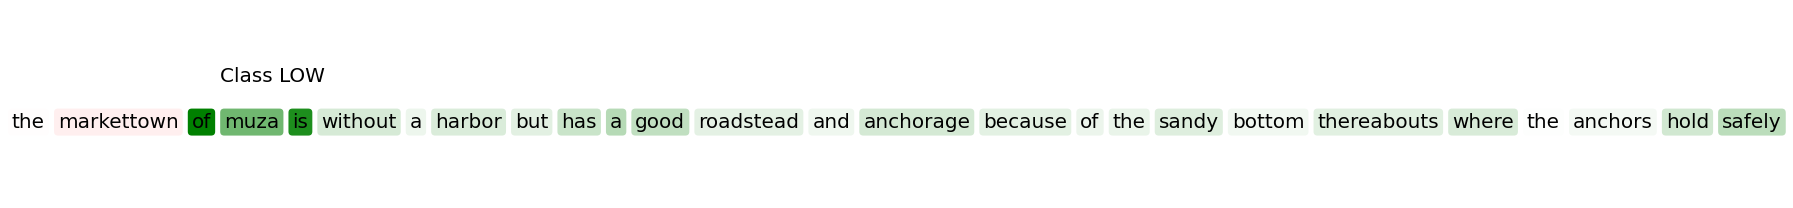

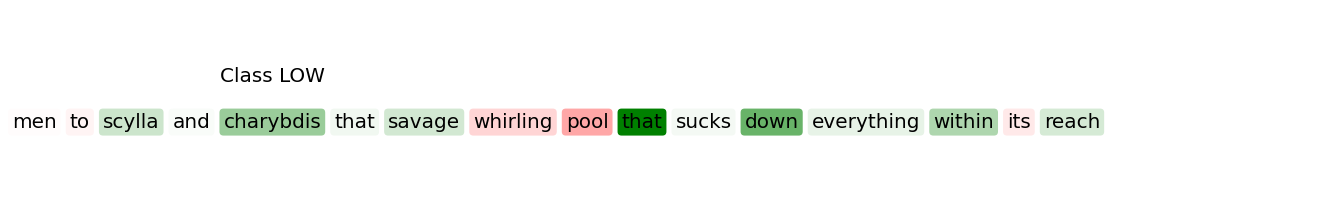

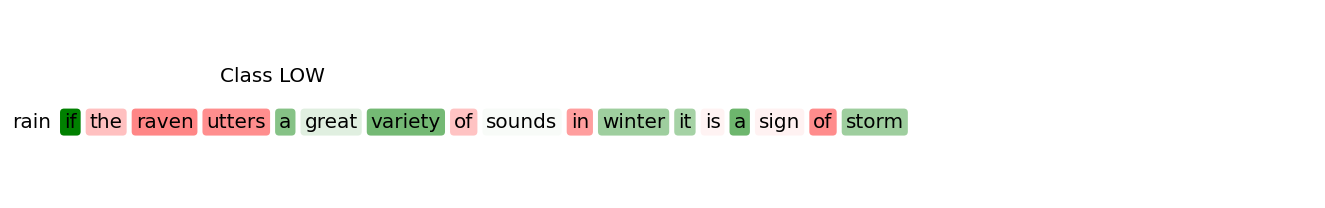

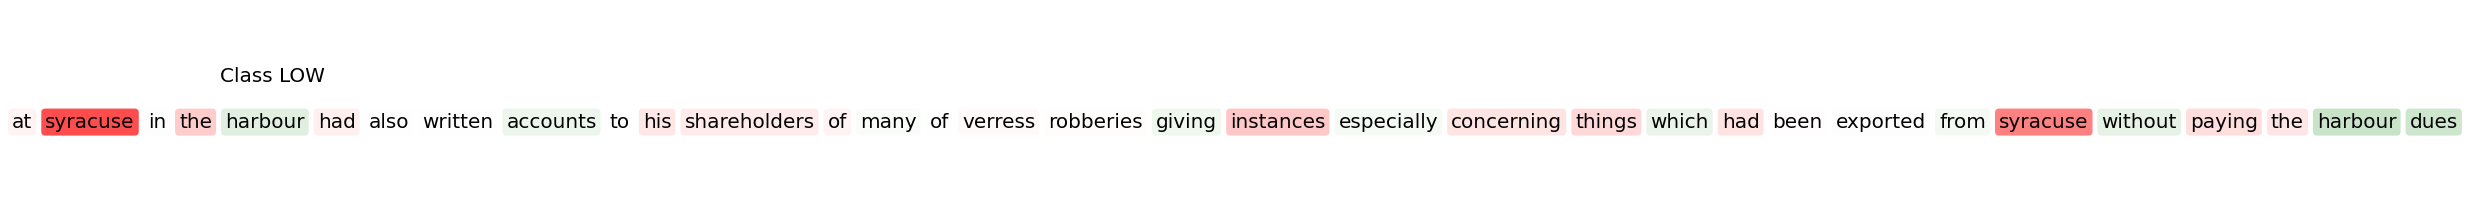

In [61]:
# label = ["HIGH", "HIGH", "HIGH", "HIGH"]
# texts = ["harbour dues at syracuse in a few months therefore as these little insignificant books show things were stolen by the praetor and exported from one single town of the value of twelve hundred thousand sesterces",
#          "harbours with bad anchorages foul inaccessible because of breakers and rocks and terrible in every way",
#          "the sirens were seamonsters who with singing voice could restrain a ship",
#          "so many monsters swarm in the water that even the air over the sea is infected with their stench"]

# label = ["MEDIUM", "MEDIUM", "MEDIUM", "MEDIUM"]
# texts = ["the sirens were seamonsters who with singing voice could restrain a ship",
#         "rain if the raven utters a great variety of sounds in winter it is a sign of storm",
#         "no harbor but a roadstead shut in by headlands projecting from the land in a manner that made it a more or less secure anchorage",
#         "since its coastline is without harbours and provides scant shelter for even small vessels nor could anyone land without being seen by the sentries"]

label = ["LOW", "LOW", "LOW", "LOW"]
texts = ["the markettown of muza is without a harbor but has a good roadstead and anchorage because of the sandy bottom thereabouts where the anchors hold safely",
         "men to scylla and charybdis that savage whirling pool that sucks down everything within its reach",
         "rain if the raven utters a great variety of sounds in winter it is a sign of storm",
         "at syracuse in the harbour had also written accounts to his shareholders of many of verress robberies giving instances especially concerning things which had been exported from syracuse without paying the harbour dues"]
shap_out = explainer(texts)
tokens_all = [tokenizer.tokenize(x) for x in texts]
preds = np.argmax(explainer.model(texts), axis=1)

for j, text in enumerate(texts):
    i = label2id[label[j]]
    tokens, scores = merge_roberta_tokens(tokens_all[j], shap_out.values[j][:, i])
    min_len = min(len(tokens), len(scores))
    
    tokens = tokens[:min_len]
    scores = scores[:min_len]
    title = f"Class {id2label[i]}"
    plot_token_attributions(title, tokens, scores, spacing=0.01, fontsize=12)